In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load Data Bersih
df = pd.read_csv('../01-Data-Preprocessing/jdm_used_cars_cleaned.csv')

# 2. Menentukan Batas Harga (Kita pakai Median agar adil 50:50)
batas_harga = df['price'].median()

# 3. Membuat kolom target baru: 1 jika Premium (> median), 0 jika Standar
df['is_premium'] = (df['price'] > batas_harga).astype(int)

# 4. MENCEGAH DATA LEAKAGE: Membuang kolom harga asli!
X = df.drop(columns=['price', 'is_premium'])
y = df['is_premium'] # Kunci Jawaban

# 5. Membagi data Ujian dan Latihan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Batas Harga Premium: Rp {batas_harga}")
print("Total Mobil Premium (1) vs Standar (0):")
print(y.value_counts())

Batas Harga Premium: Rp 1008.0
Total Mobil Premium (1) vs Standar (0):
is_premium
0    1143
1    1127
Name: count, dtype: int64


In [2]:
from sklearn.linear_model import LogisticRegression

# 1. Inisialisasi Model (max_iter ditambah agar model tidak kehabisan napas saat belajar)
model_clf = LogisticRegression(max_iter=1000, random_state=42)

# 2. Proses Belajar
model_clf.fit(X_train, y_train)

# 3. Minta model menebak soal ujian
y_pred = model_clf.predict(X_test)

print("✅ Model Klasifikasi berhasil dilatih!")

✅ Model Klasifikasi berhasil dilatih!


🏆 Akurasi Model: 63.00%



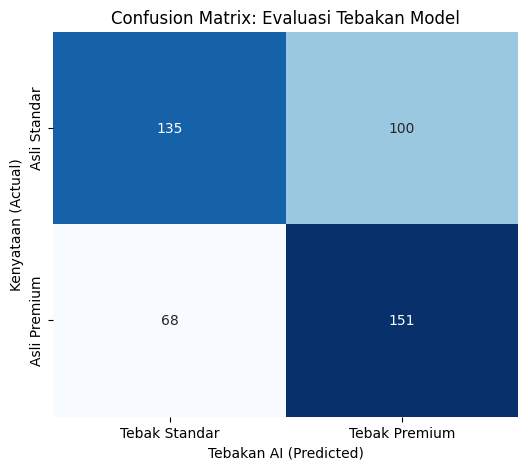

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"🏆 Akurasi Model: {akurasi * 100:.2f}%\n")

# 2. Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tebak Standar', 'Tebak Premium'],
            yticklabels=['Asli Standar', 'Asli Premium'])

plt.title('Confusion Matrix: Evaluasi Tebakan Model')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.show()